# 🎨 Color Space Analysis
### Developer: Siew Feng

This notebook demonstrates exploratory work on analyzing mango ripeness using different color spaces.

### Color Space Conversion

In [25]:
import cv2

def convert_color_spaces(image):
    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )


    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV
    )


    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )


    ycbcr = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2YCrCb
    )


    hls = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HLS
    )


    return {

        "RGB": rgb,

        "HSV": hsv,

        "LAB": lab,

        "YCbCr": ycbcr,

        "HLS": hls

    }

In [26]:
import cv2

image = cv2.imread(r"..\data\fully_ripe\IMG20200717083337.jpg")

color_space = convert_color_spaces(image)

rgb = color_space["RGB"]
hsv = color_space["HSV"]
lab = color_space["LAB"]
hls = color_space["HLS"]
ycrcb = color_space["YCbCr"]

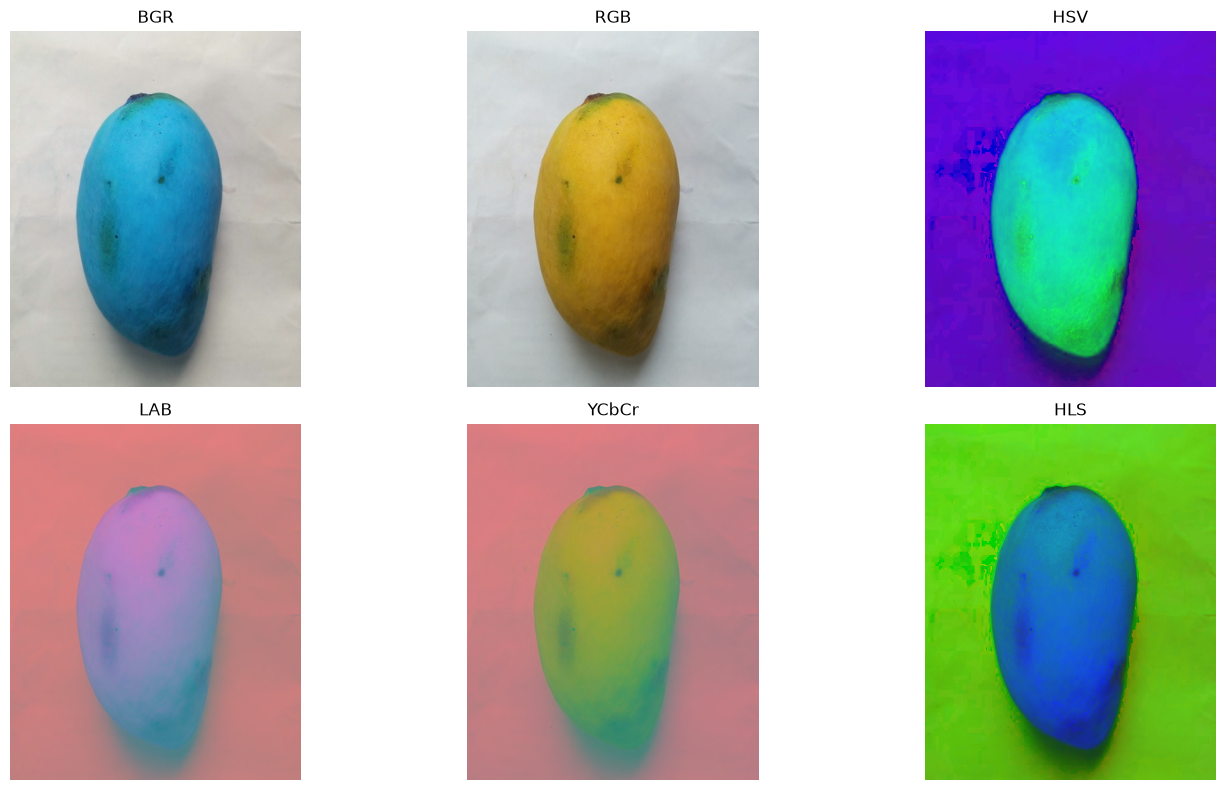

In [27]:
import matplotlib.pyplot as plt

titles = color_space.keys()

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("BGR")
plt.axis("off")

for i, (name, img) in enumerate(color_space.items()):
    i += 1
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Feature Extraction

In [28]:
import cv2
import numpy as np
def extract_channel_statistics(channel, mask, prefix):
    pixels = channel[mask > 0]

    if len(pixels) == 0:
        return {}
    
    features = {
        f"{prefix}_Mean": np.mean(pixels),
        f"{prefix}_Std": np.std(pixels),
        f"{prefix}_Min": np.min(pixels),
        f"{prefix}_Max": np.max(pixels),
        f"{prefix}_Median": np.median(pixels),
        f"{prefix}_Q25": np.percentile(pixels, 25),
        f"{prefix}_Q75": np.percentile(pixels, 75)
    }

    return features

In [29]:
import cv2

def extract_features(image, mask, color_space, channel_names):
    feature_dict = {}

    channels = cv2.split(image)

    for channel, name in zip(channels, channel_names):

        prefix = f"{color_space}_{name}"

        feature_dict.update(
            extract_channel_statistics(
                channel,
                mask,
                prefix
            )
        )

    return feature_dict

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mask = (gray > 50).astype(np.uint8) * 255

import pandas as pd

rgb_features = extract_features(
    image=rgb,
    mask=mask,
    color_space="HSV",
    channel_names=["R", "G", "B"]
)

rgb_df = pd.DataFrame([rgb_features])

print(rgb_df)

   RGB_R_Mean  RGB_R_Std  RGB_R_Min  RGB_R_Max  RGB_R_Median  RGB_R_Q25  \
0  179.905711  32.803115         56        232         185.0      172.0   

   RGB_R_Q75  RGB_G_Mean  RGB_G_Std  RGB_G_Min  ...  RGB_G_Median  RGB_G_Q25  \
0      205.0  173.545862  41.705352         48  ...         187.0      152.0   

   RGB_G_Q75  RGB_B_Mean  RGB_B_Std  RGB_B_Min  RGB_B_Max  RGB_B_Median  \
0      204.0  147.746029  77.219429          0        230         190.0   

   RGB_B_Q25  RGB_B_Q75  
0       51.0      206.0  

[1 rows x 21 columns]


### Prepare Numeric Dataset

In [31]:
import tqdm
import glob
import pandas as pd
import cv2
import numpy as np
import os

image_root = r"../cleaned_data"

datasets = ["train", "test"]

folders = [
    "overripe",
    "fully_ripe",
    "unripe"
]

output_dir = r"../output/color_based"

os.makedirs(
    output_dir,
    exist_ok=True
)

channel_mapping = {
    "RGB": ["R", "G", "B"],
    "HSV": ["H", "S", "V"],
    "LAB": ["L", "A", "B"],
    "YCbCr": ["Y", "Cb", "Cr"],
    "HLS": ["H", "L", "S"]
}

for dataset in datasets:
    print(f"\nProcessing {dataset} dataset")

    # Store results separately
    all_features = {
        "RGB": [],
        "HSV": [],
        "LAB": [],
        "YCbCr": [],
        "HLS": []
    }

    for folder in folders:
        print("\nGenerating Feature For :", folder)

        img_paths = glob.glob(
            os.path.join(
                image_root,
                dataset,
                folder,
                "*.jpg"
            )
        )

        for img_path in tqdm.tqdm(img_paths):
            img_name = os.path.basename(
                img_path
            )

            try:
                # Read image
                image = cv2.imread(
                    img_path
                )

                if image is None:
                    continue

                # ==========================
                # Create Mango Mask
                # ==========================
                gray = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGR2GRAY
                )
                mask = (
                    gray > 50
                ).astype(
                    np.uint8
                ) * 255

                # ==========================
                # Convert Color Spaces
                # ==========================
                color_spaces = convert_color_spaces(
                    image
                )

                for space_name, space_img in color_spaces.items():
                    features = extract_features(
                        image=space_img,
                        mask=mask,
                        color_space=space_name,
                        channel_names=channel_mapping[space_name]
                    )

                    # Add image information
                    features["Image_Name"] = img_name
                    features["Label"] = folder

                    all_features[space_name].append(
                        features
                    )

            except Exception as e:
                print("\nFailed:", img_name, e)


    # ====================================
    # Save each color space separately
    # ====================================
    dataset_output = os.path.join(output_dir, dataset)
    os.makedirs(dataset_output, exist_ok=True)

    for space_name, feature_list in all_features.items():
        df = pd.DataFrame(feature_list)
        output_file = os.path.join(
            dataset_output,
            f"{space_name}_features.csv"
        )
        df.to_csv(output_file, index=False)
        print("Saved:", output_file)


Processing train dataset

Generating Feature For : overripe


  0%|          | 0/192 [00:00<?, ?it/s]

100%|██████████| 192/192 [00:15<00:00, 12.52it/s]



Generating Feature For : fully_ripe


100%|██████████| 189/189 [00:12<00:00, 15.03it/s]


...


Generating Feature For : fully_ripe


100%|██████████| 48/48 [00:02<00:00, 16.85it/s]



Generating Feature For : unripe


100%|██████████| 48/48 [00:03<00:00, 14.88it/s]

Saved: ../output/color_based\test\RGB_features.csv
Saved: ../output/color_based\test\HSV_features.csv
Saved: ../output/color_based\test\LAB_features.csv
Saved: ../output/color_based\test\YCbCr_features.csv
Saved: ../output/color_based\test\HLS_features.csv


### Model Training
#### RGB

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Read CSV
train_df = pd.read_csv("../output/color_based/train/RGB_features.csv")
test_df = pd.read_csv("../output/color_based/test/RGB_features.csv")

# Features and labels
X_train = train_df[
    [
        "RGB_R_Mean",
        "RGB_R_Std",
        "RGB_R_Median",
        "RGB_G_Mean",
        "RGB_G_Std",
        "RGB_G_Median",
        "RGB_B_Mean",
        "RGB_B_Std",
        "RGB_B_Median"
    ]
]
y_train = train_df["Label"]

X_test = test_df[
    [
        "RGB_R_Mean",
        "RGB_R_Std",
        "RGB_R_Median",
        "RGB_G_Mean",
        "RGB_G_Std",
        "RGB_G_Median",
        "RGB_B_Mean",
        "RGB_B_Std",
        "RGB_B_Median"
    ]
]
y_test = test_df["Label"]

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")


# import joblib

# joblib.dump(
#     model,
#     "svm_model.pkl"
# )

# joblib.dump(
#     scaler,
#     "scaler.pkl"
# )

['RGB_R_Mean', 'RGB_R_Std', 'RGB_R_Median', 'RGB_G_Mean', 'RGB_G_Std', 'RGB_G_Median', 'RGB_B_Mean', 'RGB_B_Std', 'RGB_B_Median']
Accuracy: 97.92%


['scaler.pkl']

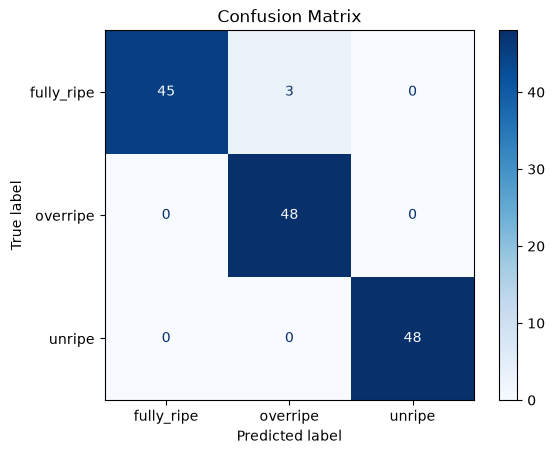

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  fully_ripe       1.00      0.94      0.97        48
    overripe       0.94      1.00      0.97        48
      unripe       1.00      1.00      1.00        48

    accuracy                           0.98       144
   macro avg       0.98      0.98      0.98       144
weighted avg       0.98      0.98      0.98       144



In [ ]:
import sys
import os

sys.path.append(r"D:\Siew Feng\IP_Assignment")

from preprocessing import preprocess_image
image_path = r"../test_images\unripe_1.jpg"

image = cv2.imread(image_path)

image = preprocess_image(image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mask = (gray > 50).astype(np.uint8) * 255

rgb = convert_color_spaces(image)["RGB"]

cv2.imshow("Processed", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
cv2.waitKey(0)
cv2.destroyAllWindows()

feature = extract_features(
    image=rgb,
    mask=mask,
    color_space="RGB",
    channel_names=["R", "G", "B"]
)

feature_df = pd.DataFrame([feature])

feature_df = feature_df[
    [
        "RGB_R_Mean",
        "RGB_R_Std",
        "RGB_R_Median",
        "RGB_G_Mean",
        "RGB_G_Std",
        "RGB_G_Median",
        "RGB_B_Mean",
        "RGB_B_Std",
        "RGB_B_Median"
    ]
]
print(feature_df)
feature_scaled = scaler.transform(feature_df)

prediction = model.predict(feature_scaled)

print("Predicted Ripeness:", prediction[0])

   RGB_R_Mean  RGB_R_Std  RGB_R_Median  RGB_G_Mean  RGB_G_Std  RGB_G_Median  \
0  120.044012  27.525469         120.0  129.839312  27.571845         130.0   

   RGB_B_Mean  RGB_B_Std  RGB_B_Median  
0   94.513948  29.559885          93.0  
Predicted Ripeness: overripe


#### HSV

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Read CSV
train_df = pd.read_csv("../output/color_based/train/HSV_features.csv")
test_df = pd.read_csv("../output/color_based/test/HSV_features.csv")

# Features and labels
X_train = train_df[
    [
        "HSV_H_Mean",
        "HSV_H_Std",
        "HSV_H_Median",
        "HSV_S_Mean",
        "HSV_S_Std",
        "HSV_S_Median",
        "HSV_V_Mean",
        "HSV_V_Std",
        "HSV_V_Median"
    ]
]
y_train = train_df["Label"]

X_test = test_df.drop(columns=["Image_Name", "Label"])
X_test = test_df[
    [
        "HSV_H_Mean",
        "HSV_H_Std",
        "HSV_H_Median",
        "HSV_S_Mean",
        "HSV_S_Std",
        "HSV_S_Median",
        "HSV_V_Mean",
        "HSV_V_Std",
        "HSV_V_Median"
    ]
]
print(X_train.columns.tolist())
y_test = test_df["Label"]

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

['HSV_H_Mean', 'HSV_H_Std', 'HSV_H_Median', 'HSV_S_Mean', 'HSV_S_Std', 'HSV_S_Median', 'HSV_V_Mean', 'HSV_V_Std', 'HSV_V_Median']
Accuracy: 97.92%


In [69]:
import sys
import os

sys.path.append(r"D:\Siew Feng\IP_Assignment")

from preprocessing import preprocess_image
image_path = r"../test_images\unripe_1.jpg"

image = cv2.imread(image_path)

image = preprocess_image(image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mask = (gray > 50).astype(np.uint8) * 255

rgb = convert_color_spaces(image)["HSV"]

feature = extract_features(
    image=rgb,
    mask=mask,
    color_space="HSV",
    channel_names=["H", "S", "V"]
)

feature_df = pd.DataFrame([feature])

feature_df = feature_df[
    [
        "HSV_H_Mean",
        "HSV_H_Std",
        "HSV_H_Median",
        "HSV_S_Mean",
        "HSV_S_Std",
        "HSV_S_Median",
        "HSV_V_Mean",
        "HSV_V_Std",
        "HSV_V_Median"
    ]
]
print(feature_df)
feature_scaled = scaler.transform(feature_df)

prediction = model.predict(feature_scaled)

print("Predicted Ripeness:", prediction[0])

   HSV_H_Mean  HSV_H_Std  HSV_H_Median  HSV_S_Mean  HSV_S_Std  HSV_S_Median  \
0   38.306356   4.795643          38.0   73.128006  23.591743          73.0   

   HSV_V_Mean  HSV_V_Std  HSV_V_Median  
0  130.010477    27.3475         130.0  
Predicted Ripeness: overripe


#### YCbCr

In [89]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Read CSV
train_df = pd.read_csv("../output/color_based/train/YCbCr_features.csv")
test_df = pd.read_csv("../output/color_based/test/YCbCr_features.csv")

# Features and labels
X_train = train_df[
    [
        "YCbCr_Y_Mean",
        "YCbCr_Y_Std",
        "YCbCr_Y_Median",
        "YCbCr_Cb_Mean",
        "YCbCr_Cb_Std",
        "YCbCr_Cb_Median",
        "YCbCr_Cr_Mean",
        "YCbCr_Cr_Std",
        "YCbCr_Cr_Median"
    ]
]
y_train = train_df["Label"]

X_test = test_df[
    [
        "YCbCr_Y_Mean",
        "YCbCr_Y_Std",
        "YCbCr_Y_Median",
        "YCbCr_Cb_Mean",
        "YCbCr_Cb_Std",
        "YCbCr_Cb_Median",
        "YCbCr_Cr_Mean",
        "YCbCr_Cr_Std",
        "YCbCr_Cr_Median"
    ]
]
print(X_train.columns.tolist())
y_test = test_df["Label"]

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

['YCbCr_Y_Mean', 'YCbCr_Y_Std', 'YCbCr_Y_Median', 'YCbCr_Cb_Mean', 'YCbCr_Cb_Std', 'YCbCr_Cb_Median', 'YCbCr_Cr_Mean', 'YCbCr_Cr_Std', 'YCbCr_Cr_Median']
Accuracy: 94.44%


In [90]:
import sys
import os

sys.path.append(r"D:\Siew Feng\IP_Assignment")

from preprocessing import preprocess_image
image_path = r"../test_images\overripe_2.jpg"

image = cv2.imread(image_path)

image = preprocess_image(image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mask = (gray > 50).astype(np.uint8) * 255

rgb = convert_color_spaces(image)["YCbCr"]

feature = extract_features(
    image=rgb,
    mask=mask,
    color_space="YCbCr",
    channel_names=["Y", "Cb", "Cr"]
)

feature_df = pd.DataFrame([feature])

feature_df = feature_df[
    [
        "YCbCr_Y_Mean",
        "YCbCr_Y_Std",
        "YCbCr_Y_Median",
        "YCbCr_Cb_Mean",
        "YCbCr_Cb_Std",
        "YCbCr_Cb_Median",
        "YCbCr_Cr_Mean",
        "YCbCr_Cr_Std",
        "YCbCr_Cr_Median"
    ]
]
print(feature_df)
feature_scaled = scaler.transform(feature_df)

prediction = model.predict(feature_scaled)

print("Predicted Ripeness:", prediction[0])

   YCbCr_Y_Mean  YCbCr_Y_Std  YCbCr_Y_Median  YCbCr_Cb_Mean  YCbCr_Cb_Std  \
0    144.668637    32.931098           147.0     155.780135      7.262149   

   YCbCr_Cb_Median  YCbCr_Cr_Mean  YCbCr_Cr_Std  YCbCr_Cr_Median  
0            157.0      70.295878     15.935683             69.0  
Predicted Ripeness: fully_ripe


#### LAB

In [80]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Read CSV
train_df = pd.read_csv("../output/color_based/train/LAB_features.csv")
test_df = pd.read_csv("../output/color_based/test/LAB_features.csv")

# Features and labels
X_train = train_df[
    [
        "LAB_L_Mean",
        "LAB_L_Std",
        "LAB_L_Median",
        "LAB_A_Mean",
        "LAB_A_Std",
        "LAB_A_Median",
        "LAB_B_Mean",
        "LAB_B_Std",
        "LAB_B_Median"
    ]
]
y_train = train_df["Label"]

X_test = test_df[
    [
        "LAB_L_Mean",
        "LAB_L_Std",
        "LAB_L_Median",
        "LAB_A_Mean",
        "LAB_A_Std",
        "LAB_A_Median",
        "LAB_B_Mean",
        "LAB_B_Std",
        "LAB_B_Median"
    ]
]
print(X_train.columns.tolist())
y_test = test_df["Label"]

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

['LAB_L_Mean', 'LAB_L_Std', 'LAB_L_Median', 'LAB_A_Mean', 'LAB_A_Std', 'LAB_A_Median', 'LAB_B_Mean', 'LAB_B_Std', 'LAB_B_Median']
Accuracy: 97.22%


In [87]:
import sys
import os

sys.path.append(r"D:\Siew Feng\IP_Assignment")

from preprocessing import preprocess_image
image_path = r"../test_images\overripe_2.jpg"

image = cv2.imread(image_path)

image = preprocess_image(image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mask = (gray > 50).astype(np.uint8) * 255

rgb = convert_color_spaces(image)["LAB"]

feature = extract_features(
    image=rgb,
    mask=mask,
    color_space="LAB",
    channel_names=["L", "A", "B"]
)

feature_df = pd.DataFrame([feature])

feature_df = feature_df[
    [
        "LAB_L_Mean",
        "LAB_L_Std",
        "LAB_L_Median",
        "LAB_A_Mean",
        "LAB_A_Std",
        "LAB_A_Median",
        "LAB_B_Mean",
        "LAB_B_Std",
        "LAB_B_Median"
    ]
]
print(feature_df)
feature_scaled = scaler.transform(feature_df)

prediction = model.predict(feature_scaled)

print("Predicted Ripeness:", prediction[0])

   LAB_L_Mean  LAB_L_Std  LAB_L_Median  LAB_A_Mean  LAB_A_Std  LAB_A_Median  \
0  158.036668  31.770399         162.0  133.433094   4.318745         133.0   

   LAB_B_Mean  LAB_B_Std  LAB_B_Median  
0  181.644172  12.581675         184.0  
Predicted Ripeness: fully_ripe


#### HLS

In [91]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Read CSV
train_df = pd.read_csv("../output/color_based/train/HLS_features.csv")
test_df = pd.read_csv("../output/color_based/test/HLS_features.csv")

# Features and labels
X_train = train_df[
    [
        "HLS_H_Mean",
        "HLS_H_Std",
        "HLS_H_Median",
        "HLS_L_Mean",
        "HLS_L_Std",
        "HLS_L_Median",
        "HLS_S_Mean",
        "HLS_S_Std",
        "HLS_S_Median"
    ]
]
y_train = train_df["Label"]

X_test = test_df[
    [
        "HLS_H_Mean",
        "HLS_H_Std",
        "HLS_H_Median",
        "HLS_L_Mean",
        "HLS_L_Std",
        "HLS_L_Median",
        "HLS_S_Mean",
        "HLS_S_Std",
        "HLS_S_Median"
    ]
]
print(X_train.columns.tolist())
y_test = test_df["Label"]

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

['HLS_H_Mean', 'HLS_H_Std', 'HLS_H_Median', 'HLS_L_Mean', 'HLS_L_Std', 'HLS_L_Median', 'HLS_S_Mean', 'HLS_S_Std', 'HLS_S_Median']
Accuracy: 98.61%


In [98]:
import sys
import os

sys.path.append(r"D:\Siew Feng\IP_Assignment")

from preprocessing import preprocess_image
image_path = r"../test_images\ripe_2.jpg"

image = cv2.imread(image_path)

image = preprocess_image(image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mask = (gray > 50).astype(np.uint8) * 255

rgb = convert_color_spaces(image)["HLS"]

feature = extract_features(
    image=rgb,
    mask=mask,
    color_space="HLS",
    channel_names=["H", "L", "S"]
)

feature_df = pd.DataFrame([feature])

feature_df = feature_df[
    [
        "HLS_H_Mean",
        "HLS_H_Std",
        "HLS_H_Median",
        "HLS_L_Mean",
        "HLS_L_Std",
        "HLS_L_Median",
        "HLS_S_Mean",
        "HLS_S_Std",
        "HLS_S_Median"
    ]
]
print(feature_df)
feature_scaled = scaler.transform(feature_df)

prediction = model.predict(feature_scaled)

print("Predicted Ripeness:", prediction[0])

   HLS_H_Mean  HLS_H_Std  HLS_H_Median  HLS_L_Mean  HLS_L_Std  HLS_L_Median  \
0   21.642595   2.310562          22.0  123.836622  22.277927         122.0   

   HLS_S_Mean  HLS_S_Std  HLS_S_Median  
0  233.406633  37.283481         255.0  
Predicted Ripeness: overripe
